## Run ResNet-50 

**TASK:** Detect Insect Type \
**Dataset:** iNaturalist \
**Model:** Resnet-50 (pretrained)

In [10]:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # silence tensorflow logging
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import models, transforms
from PIL import Image, ImageFile
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt

from utils.label_mappings import iNat_to_clean_map

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Loading

In [13]:
# custom mapping
class_dirs = ['Ant', 'Bee', 'Beetle', 'Butterfly', 'Grasshopper', 'Ladybug', 'Spider']
all_classes = class_dirs + ['Other']
num_classes = len(all_classes)
global_label_to_idx = {name: i for i, name in enumerate(all_classes)}

In [14]:
# resize images to be standard size for ResNet inputs
# uses ImageNet's mean and standard deviation to match the pre-trained weights
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [15]:
# load iNaturalist dataset via Hugging Face
ds = load_dataset("sxj1215/inaturalist", split='train')

def get_iNat_label(messages): 
    return messages[1]['content']

In [16]:
# map labels
iNat36_label_df = pd.DataFrame({'messages': ds['messages']})
iNat36_label_df['species'] = iNat36_label_df['messages'].apply(lambda m: m[1]['content'])
iNat36_label_df['clean_label'] = iNat36_label_df['species'].map(
    lambda x: iNat_to_clean_map.get(x, 'Other') if iNat_to_clean_map.get(x) in class_dirs else 'Other'
)

In [17]:
# all valid insects for random/full experiments
all_indices = list(range(len(iNat36_label_df))) 

In [18]:
raw_curated = np.load('data/kairos_output/finetuning_indexes_full_curated.npy').tolist()

# extracting only the 7 target insect classes
cur_indices = [i for i in raw_curated if iNat36_label_df.iloc[i]['clean_label'] != 'Other']

In [19]:
# dataset classes (tell PyTorch how to read specific data formats)

class InatPixelDataset(Dataset):
    def __init__(self, hf_dataset, indices, label_df, transform=None):
        self.hf_dataset, self.indices, self.label_df, self.transform = hf_dataset, indices, label_df, transform
    
    def __len__(self): 
        return len(self.indices)
    
    def __getitem__(self, idx):
        # fetches image and looks up the corresponding "clean" label string, converting it to a number using global_label_to_idx
        orig_idx = self.indices[idx]
        image = self.hf_dataset[orig_idx]['images'][0]
        label_str = self.label_df.iloc[orig_idx]['clean_label']
        if self.transform: 
            image = self.transform(image)
        return image, torch.tensor(global_label_to_idx[label_str], dtype=torch.long)

In [20]:
class KaggleTestDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths, self.transform = file_paths, transform
    
    def __len__(self): 
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # extracts label from folder name
        path = self.file_paths[idx]
        label_name = os.path.basename(os.path.dirname(path))
        image = Image.open(path).convert('RGB')
        if self.transform: 
            image = self.transform(image)
        return image, torch.tensor(global_label_to_idx[label_name], dtype=torch.long)

In [21]:
# test set loading

test_base_path = 'data/clean_insect_images/'
test_files = []

for c in class_dirs:
    p = os.path.join(test_base_path, c)
    if os.path.exists(p):
        test_files.extend([os.path.join(p, f) for f in os.listdir(p) if f.lower().endswith(('.jpg', '.png'))])

test_loader = DataLoader(KaggleTestDataset(test_files, transform=preprocess), batch_size=32, shuffle=False)

### Model Functions

In [22]:
def get_partial_unfreeze_model():
    # loads ResNet-50 with pre-trained weights
    model = models.resnet50(weights="IMAGENET1K_V1")

    # replaces final layer to match number of classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    # freezes all parameters
    for param in model.parameters(): 
        param.requires_grad = False
    
    # unfreezes only layer4 (final block of convolutions) and fc layer for training
    for param in model.layer4.parameters(): 
        param.requires_grad = True
    
    for param in model.fc.parameters(): 
        param.requires_grad = True
        
    return model

In [23]:
def get_lora_model():
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    # Targeting the main convolution layers (conv1, conv2, conv3) in bottleneck blocks
    # and the fully connected layer.

    # adds low-rank matrices to specific layers
    # rank=64 and lora_alpha=128 to better handle complex/noisy data
    config = LoraConfig(
        r=64,             
        lora_alpha=128,     
        target_modules=["fc", "conv1", "conv2", "conv3"], 
        lora_dropout=0.05,   # lower dropout to retain more signal
        bias="none"
    )
    
    return get_peft_model(model, config)

In [24]:
def get_baseline_model(num_classes):
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [25]:
def run_experiment(name, model_fn, dataset, test_loader):
    print(f"\n--- Starting Experiment: {name} ---")
    
    # split dataset into train (80%) and val (20%)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_set, val_set = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    t_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    v_loader = DataLoader(val_set, batch_size=32, shuffle=False)
    
    model = model_fn().to(device)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # metrics storage
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # training loop
    start_train_time = time.time()
    
    # runs for 4 epochs
    for epoch in range(4):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for imgs, labels in t_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # epoch stats
            train_loss += loss.item() * imgs.size(0)
            train_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            train_total += labels.size(0)

        # val phase for this epoch
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in v_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
                val_total += labels.size(0)

        # append to history
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(val_correct / val_total)

        print(f"Epoch {epoch+1}/3 - Train Acc: {history['train_acc'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}")

    train_time = time.time() - start_train_time

    # final test evaluation on test_loader
    model.eval()
    test_preds, test_probs, test_targets = [], [], []
    
    start_test_time = time.time()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = torch.softmax(out, dim=1)
            
            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            test_targets.extend(labels.numpy())
    test_time = time.time() - start_test_time
    
    # metric calculations
    probs_array = np.array(test_probs)[:, :7] 
    probs_array = probs_array / probs_array.sum(axis=1, keepdims=True)
    
    acc = accuracy_score(test_targets, test_preds)
    f1 = f1_score(test_targets, test_preds, average='weighted')
    auc = roc_auc_score(test_targets, probs_array, multi_class='ovr', average='weighted')

    # print outputs
    print(f"Results for {name}:")
    print(f"  Test Accuracy:  {acc:.4f}")
    print(f"  Test Weight F1: {f1:.4f}")
    print(f"  Test AUC:       {auc:.4f}")
    print(f"  Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")

    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_dirs, yticklabels=class_dirs)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    res = {
        'name': name,
        'acc': acc,
        'f1': f1,
        'auc': auc,
        'train_time': train_time,
        'test_time': test_time,
        'conf_matrix': cm,
        'history': history #epoch metrics
    }
    return res

In [26]:
def run_multiple_trials(name, model_fn, dataset, test_loader, num_trials=5):
    all_results = []
    
    for i in range(num_trials):
        print(f"\n>>> {name} - Trial {i+1}/{num_trials}")
        
        # different seed for each trial for reproducibility of splits
        torch.manual_seed(42 + i)
        np.random.seed(42 + i)
        
        res = run_experiment(f"{name}_T{i+1}", model_fn, dataset, test_loader)
        all_results.append(res)
    
    # aggregate metrics
    metrics = ['acc', 'f1', 'auc']
    summary = {'name': name}
    
    print(f"\n{'='*30}\nFinal Summary for {name}\n{'='*30}")
    for m in metrics:
        values = [r[m] for r in all_results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        summary[f'{m}_mean'] = mean_val
        summary[f'{m}_std'] = std_val
        print(f"{m.upper()}: {mean_val:.4f} +/- {std_val:.4f}")
        
    return summary, all_results

In [ ]:
def evaluate_baseline(model, test_loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    test_preds, test_probs, test_targets = [], [], []
    start_time = time.time()
    
    print(f"Starting evaluation")
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            
            # get softmax probabilities
            probs = torch.softmax(outputs, dim=1)
            # get predicted class index
            preds = torch.argmax(outputs, dim=1)
            
            test_probs.extend(probs.cpu().numpy())
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(labels.numpy())
            
    total_time = time.time() - start_time
    
    test_probs_np = np.array(test_probs)
    num_model_outputs = test_probs_np.shape[1]
    num_expected_classes = len(class_names)
    
    if num_model_outputs > num_expected_classes:
        test_probs_final = test_probs_np[:, :num_expected_classes]
        test_probs_final = test_probs_final / (test_probs_final.sum(axis=1, keepdims=True) + 1e-10)
    else:
        test_probs_final = test_probs_np

    test_preds_final = [min(p, num_expected_classes - 1) for p in test_preds]
    unique_labels = np.arange(num_expected_classes)

    # metric calculations
    acc = accuracy_score(test_targets, test_preds_final)
    f1 = f1_score(test_targets, test_preds_final, average='weighted')
    
    auc = roc_auc_score(
            test_targets, 
            test_probs_final, 
            multi_class='ovr', 
            average='weighted', 
            labels=unique_labels
        )
    
    print(f"\n--- BASELINE METRICS ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"Time:      {total_time:.2f}s")
    
    # visualization
    cm = confusion_matrix(test_targets, test_preds_final, labels=unique_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Baseline Evaluation')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    

In [28]:
def run_multiple_trials_baseline(model_fn, test_loader, class_names, num_trials=5):
    all_results = []
    print(f"\n--- Starting Baseline Evaluation ({num_trials} trials) ---")
    
    for i in range(num_trials):
        print(f"\n>>> Baseline Trial {i+1}/{num_trials}")
        
        torch.manual_seed(42 + i)
        
        model = model_fn(len(class_names))
        
        res = evaluate_baseline(model, test_loader, class_names)
        all_results.append(res)
    
    metrics = ['acc', 'f1', 'auc']
    summary = {'name': 'Baseline (No Training)'}
    
    print(f"\n{'='*40}")
    print(f"Final Statistics for Baseline")
    print(f"{'='*40}")
    
    for m in metrics:
        values = [r[m] for r in all_results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        summary[f'{m}_mean'] = mean_val
        summary[f'{m}_std'] = std_val
        print(f"{m.upper()}: {mean_val:.4f} +/- {std_val:.4f}")
        
    return summary, all_results

## Experiments

In [29]:
results_summary = {}

#### Baseline (no training)

In [31]:
results_summary['Baseline'] = run_multiple_trials_baseline(get_baseline_model, test_loader, class_dirs, 5)


--- Starting Baseline Evaluation (5 trials) ---

>>> Baseline Trial 1/5
Starting evaluation: Expected 7 classes.


KeyboardInterrupt: 

### Experiment 1: Original Training Data

#### 1.1: Curated

Trains ResNet-50 model on only the highest value samples identified by KAIROS.

In [38]:
raw_curated = np.load('data/kairos_output/finetuning_indexes_full_curated.npy').tolist()

# ensures the model only trains on the 7 target insect classes
cur_ds = InatPixelDataset(ds, cur_indices, iNat36_label_df, transform=preprocess)

##### Partial Unfreezing

In [42]:
results_summary['Curated_partial'] = run_multiple_trials("Curated (Partial Unfreezing)", 
                                            get_partial_unfreeze_model, 
                                            cur_ds,
                                            test_loader, 
                                            num_trials=5
                                        )


>>> Curated_partial - Trial 1/5

--- Starting Experiment: Curated_partial_T1 ---


KeyboardInterrupt: 

##### LoRA


>>> LoRA Curated - Trial 1/5

--- Starting Experiment: LoRA Curated_T1 ---
Epoch 1/3 - Train Acc: 0.6004, Val Acc: 0.8660
Epoch 2/3 - Train Acc: 0.9174, Val Acc: 0.9660
Epoch 3/3 - Train Acc: 0.9771, Val Acc: 0.9660
Results for LoRA Curated_T1:
  Test Accuracy:  0.7863
  Test Weight F1: 0.7756
  Test AUC:       0.9683
  Train Time: 328.17s | Test Time: 262.5059s


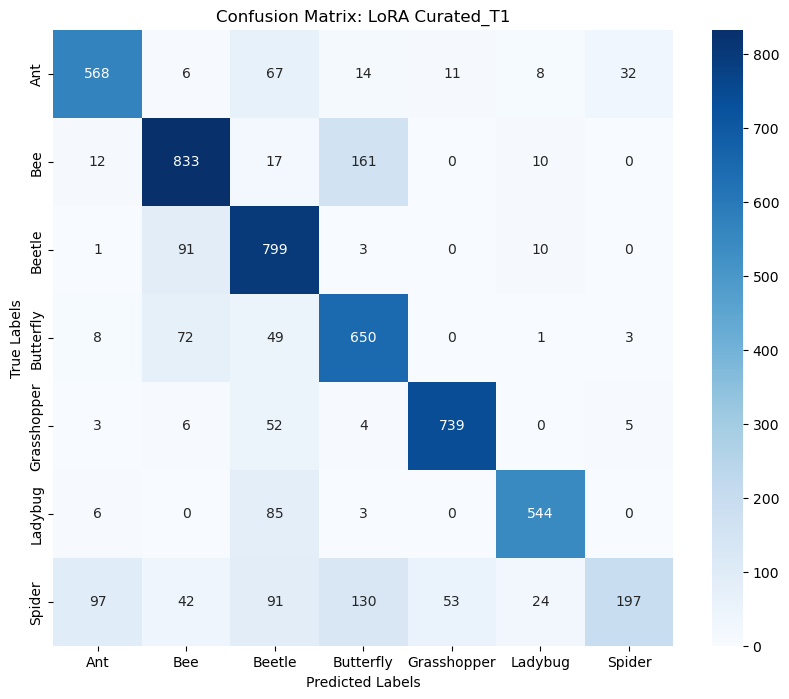


>>> LoRA Curated - Trial 2/5

--- Starting Experiment: LoRA Curated_T2 ---
Epoch 1/3 - Train Acc: 0.5924, Val Acc: 0.8617
Epoch 2/3 - Train Acc: 0.9270, Val Acc: 0.9447
Epoch 3/3 - Train Acc: 0.9792, Val Acc: 0.9532
Results for LoRA Curated_T2:
  Test Accuracy:  0.7865
  Test Weight F1: 0.7722
  Test AUC:       0.9668
  Train Time: 313.24s | Test Time: 319.5451s


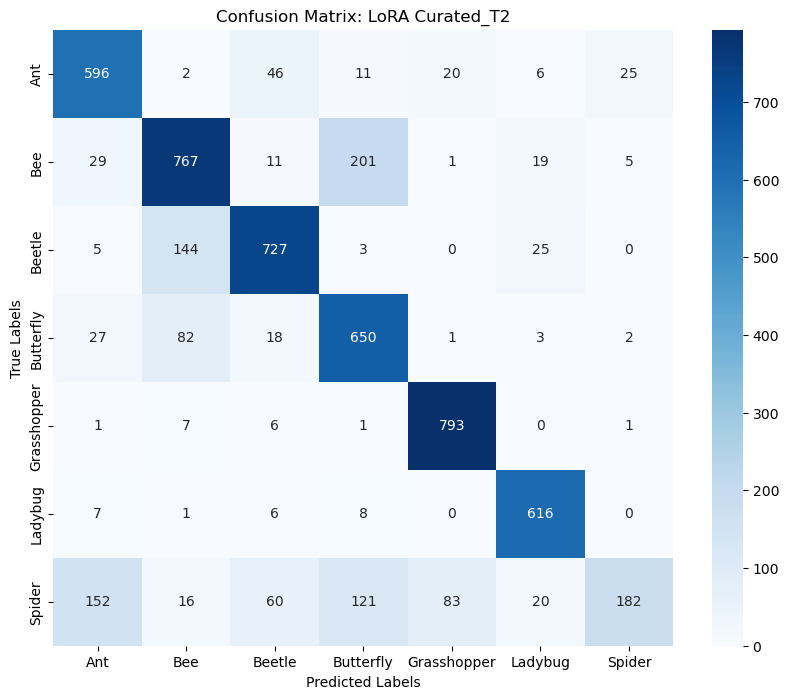


>>> LoRA Curated - Trial 3/5

--- Starting Experiment: LoRA Curated_T3 ---
Epoch 1/3 - Train Acc: 0.6079, Val Acc: 0.8681
Epoch 2/3 - Train Acc: 0.9126, Val Acc: 0.9511
Epoch 3/3 - Train Acc: 0.9782, Val Acc: 0.9532
Results for LoRA Curated_T3:
  Test Accuracy:  0.7835
  Test Weight F1: 0.7655
  Test AUC:       0.9668
  Train Time: 469.21s | Test Time: 264.2783s


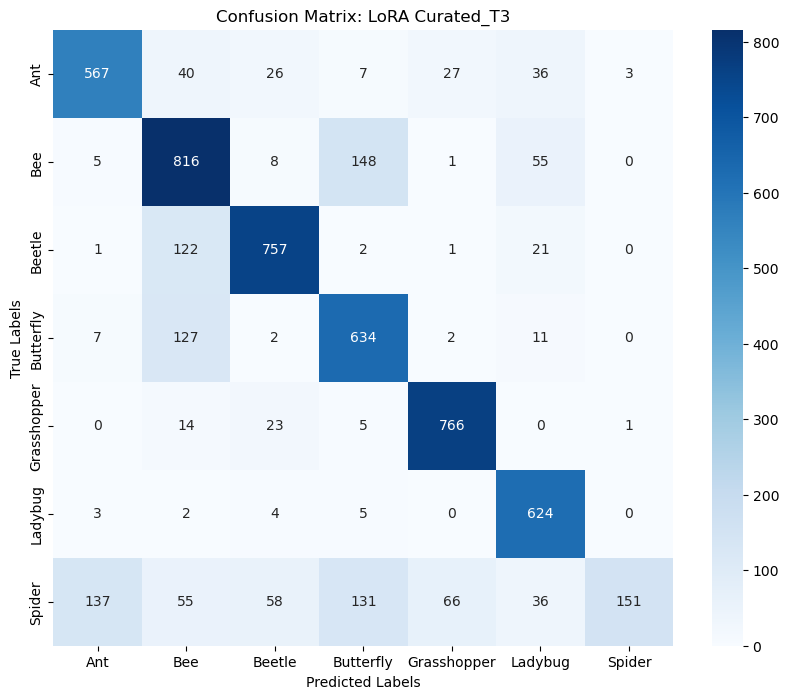


>>> LoRA Curated - Trial 4/5

--- Starting Experiment: LoRA Curated_T4 ---
Epoch 1/3 - Train Acc: 0.5834, Val Acc: 0.8553
Epoch 2/3 - Train Acc: 0.9227, Val Acc: 0.9532
Epoch 3/3 - Train Acc: 0.9798, Val Acc: 0.9532
Results for LoRA Curated_T4:
  Test Accuracy:  0.7745
  Test Weight F1: 0.7510
  Test AUC:       0.9707
  Train Time: 376.10s | Test Time: 282.0835s


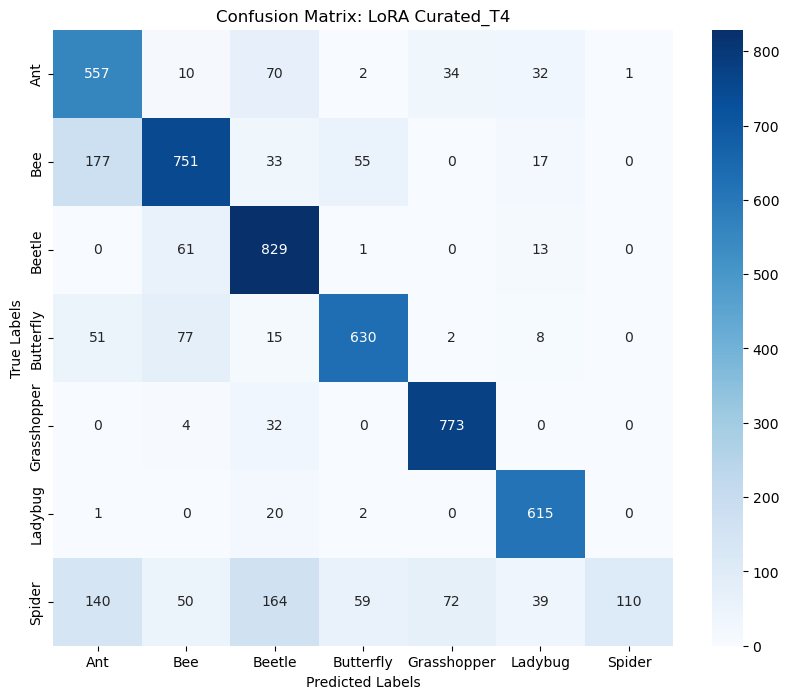


>>> LoRA Curated - Trial 5/5

--- Starting Experiment: LoRA Curated_T5 ---
Epoch 1/3 - Train Acc: 0.5956, Val Acc: 0.8553
Epoch 2/3 - Train Acc: 0.9233, Val Acc: 0.9383
Epoch 3/3 - Train Acc: 0.9755, Val Acc: 0.9426
Results for LoRA Curated_T5:
  Test Accuracy:  0.7647
  Test Weight F1: 0.7545
  Test AUC:       0.9628
  Train Time: 449.61s | Test Time: 431.0858s


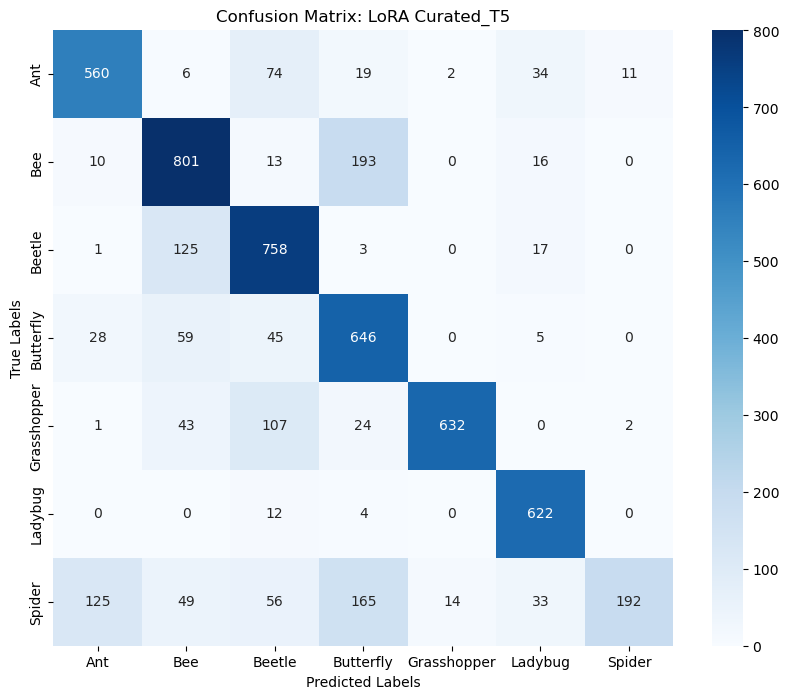


Final Summary for LoRA Curated
ACC: 0.7791 +/- 0.0084
F1: 0.7638 +/- 0.0096
AUC: 0.9671 +/- 0.0026


In [41]:
results_summary['Curated_LoRA'] = run_multiple_trials("Curated (LoRA)", 
                                            get_lora_model, 
                                            cur_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

#### 1.2: Full iNat

Trains ResNet-50 model on the entire available iNaturalist training set.


--- Starting Experiment: Full iNat (Partial Unfreezing) ---
Results for Full iNat (Partial Unfreezing):
  Test Accuracy:  0.6219
  Test Weight F1: 0.6998
  Test AUC:       0.9599
  Train Time: 1681.02s | Test Time: 180.4809s
  Confusion Matrix:


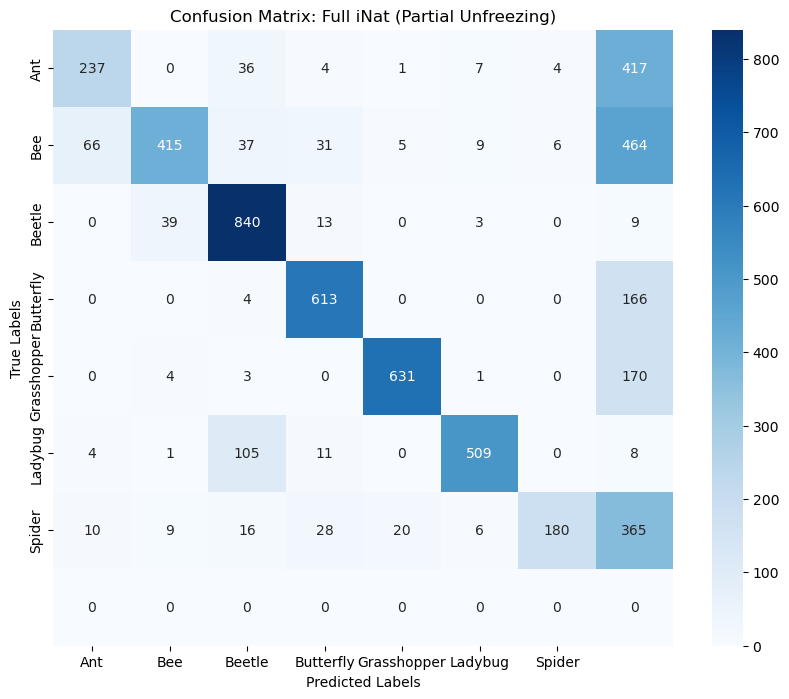

In [37]:
full_ds = InatPixelDataset(ds, all_indices, iNat36_label_df, transform=preprocess)

##### Partial Unfreezing

In [ ]:
results_summary['Full_partial'] = run_multiple_trials("Full iNat (Partial Unfreezing)", 
                                            get_partial_unfreeze_model, 
                                            full_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

##### LoRA

In [ ]:
results_summary['Full_LoRA'] = run_multiple_trials("Full iNat (LoRA)", 
                                            get_lora_model, 
                                            full_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

#### 1.3: Random Sample

Trains ResNet-50 model on 10 random subsets (same size as curated) of the iNaturalist data.

##### Partial Unfreezing


--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5618
  Test Weight F1: 0.6408
  Test AUC:       0.9600
  Train Time: 109.22s | Test Time: 174.2840s
  Confusion Matrix:


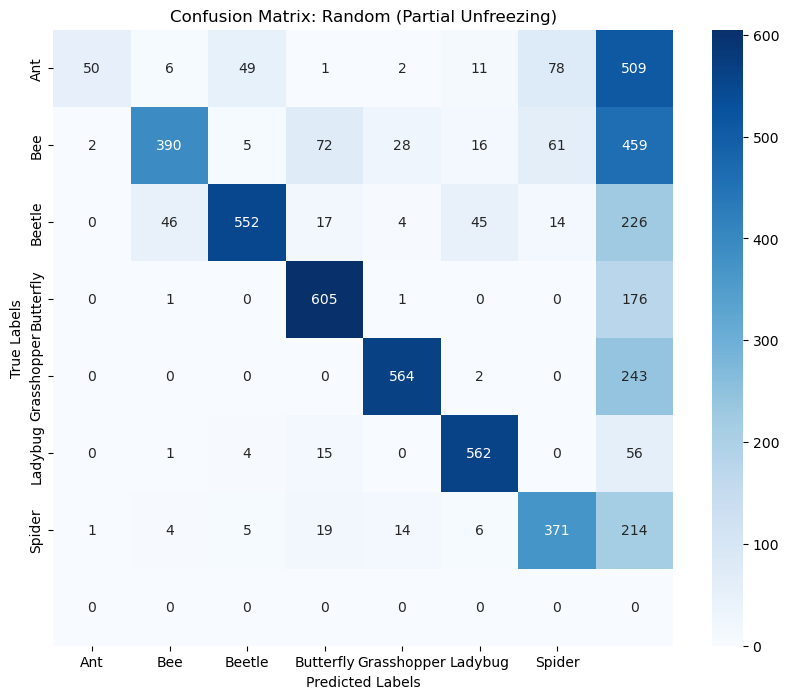

RESULT [Trial 1/10]: Acc: 0.5618 | F1: 0.6408 | AUC: 0.9600

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4474
  Test Weight F1: 0.5113
  Test AUC:       0.9338
  Train Time: 105.48s | Test Time: 180.9864s
  Confusion Matrix:


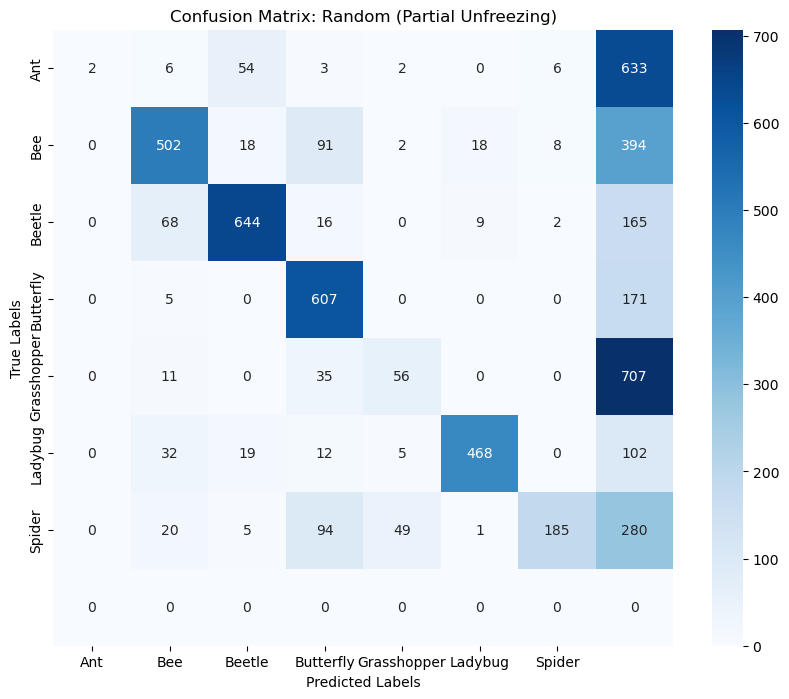

RESULT [Trial 2/10]: Acc: 0.4474 | F1: 0.5113 | AUC: 0.9338

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5170
  Test Weight F1: 0.5457
  Test AUC:       0.9535
  Train Time: 112.76s | Test Time: 182.9593s
  Confusion Matrix:


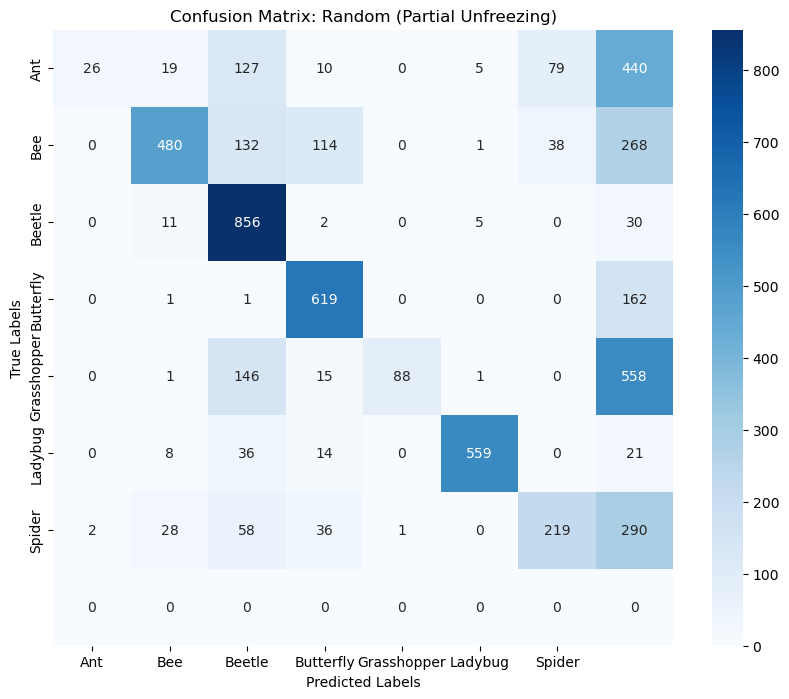

RESULT [Trial 3/10]: Acc: 0.5170 | F1: 0.5457 | AUC: 0.9535

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5242
  Test Weight F1: 0.5987
  Test AUC:       0.9479
  Train Time: 110.08s | Test Time: 186.1831s
  Confusion Matrix:


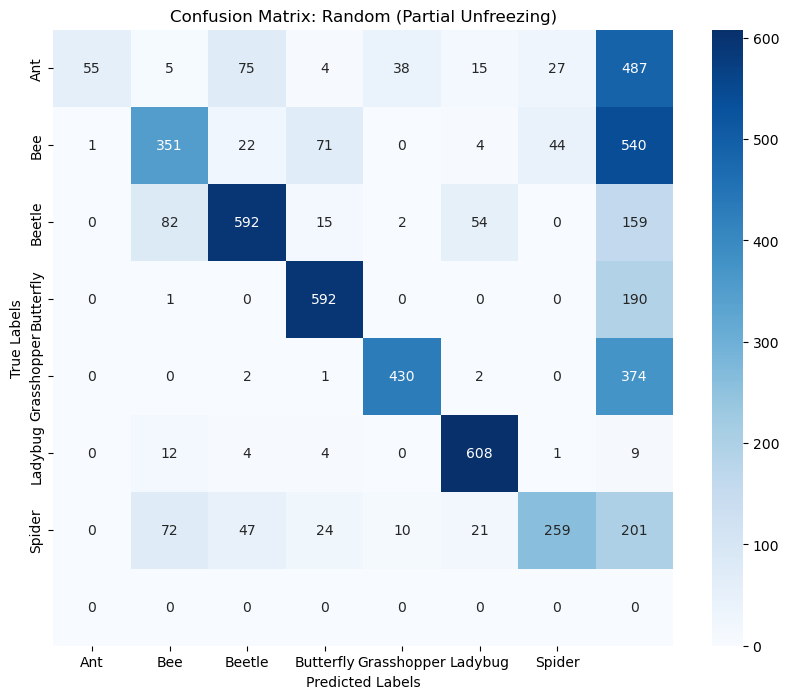

RESULT [Trial 4/10]: Acc: 0.5242 | F1: 0.5987 | AUC: 0.9479

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4549
  Test Weight F1: 0.5218
  Test AUC:       0.9399
  Train Time: 113.33s | Test Time: 213.0076s
  Confusion Matrix:


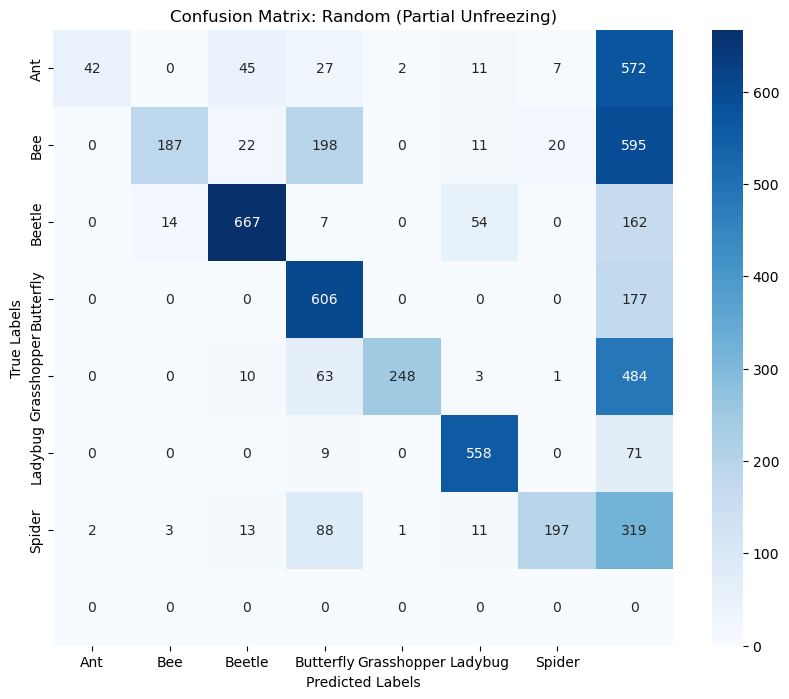

RESULT [Trial 5/10]: Acc: 0.4549 | F1: 0.5218 | AUC: 0.9399

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.3917
  Test Weight F1: 0.4634
  Test AUC:       0.9228
  Train Time: 148.45s | Test Time: 237.9799s
  Confusion Matrix:


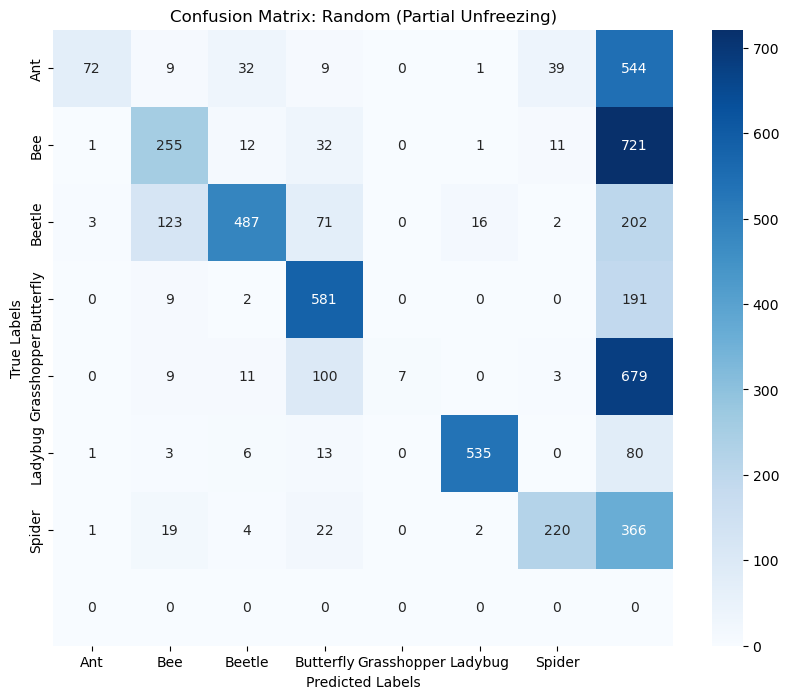

RESULT [Trial 6/10]: Acc: 0.3917 | F1: 0.4634 | AUC: 0.9228

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.3657
  Test Weight F1: 0.4194
  Test AUC:       0.9113
  Train Time: 149.87s | Test Time: 238.7313s
  Confusion Matrix:


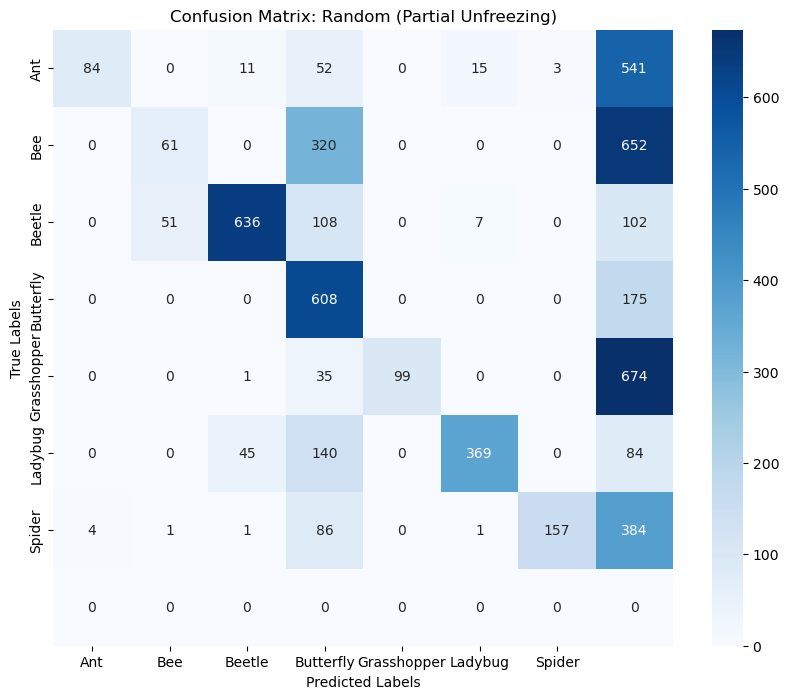

RESULT [Trial 7/10]: Acc: 0.3657 | F1: 0.4194 | AUC: 0.9113

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4718
  Test Weight F1: 0.5192
  Test AUC:       0.9472
  Train Time: 149.86s | Test Time: 238.0868s
  Confusion Matrix:


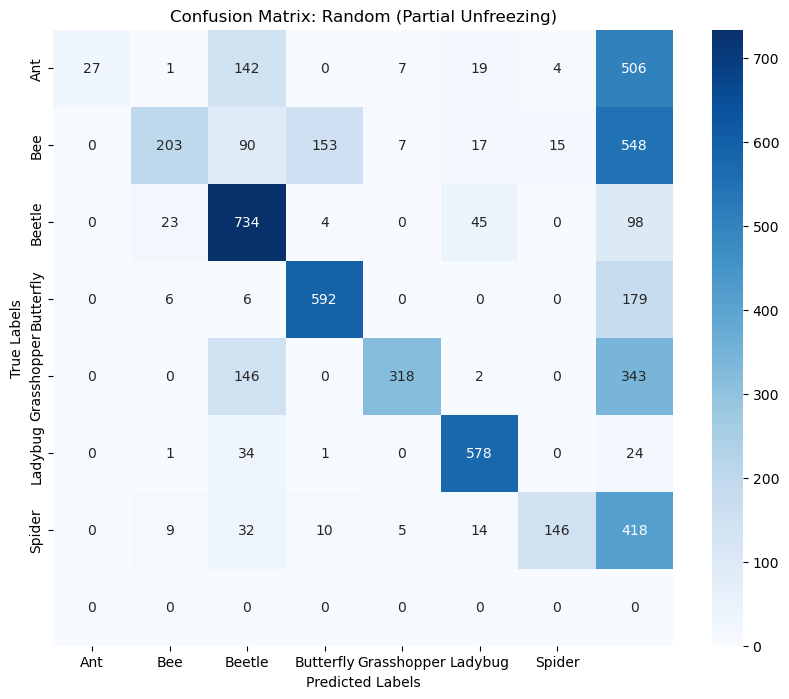

RESULT [Trial 8/10]: Acc: 0.4718 | F1: 0.5192 | AUC: 0.9472

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.5141
  Test Weight F1: 0.5723
  Test AUC:       0.9466
  Train Time: 150.41s | Test Time: 239.0683s
  Confusion Matrix:


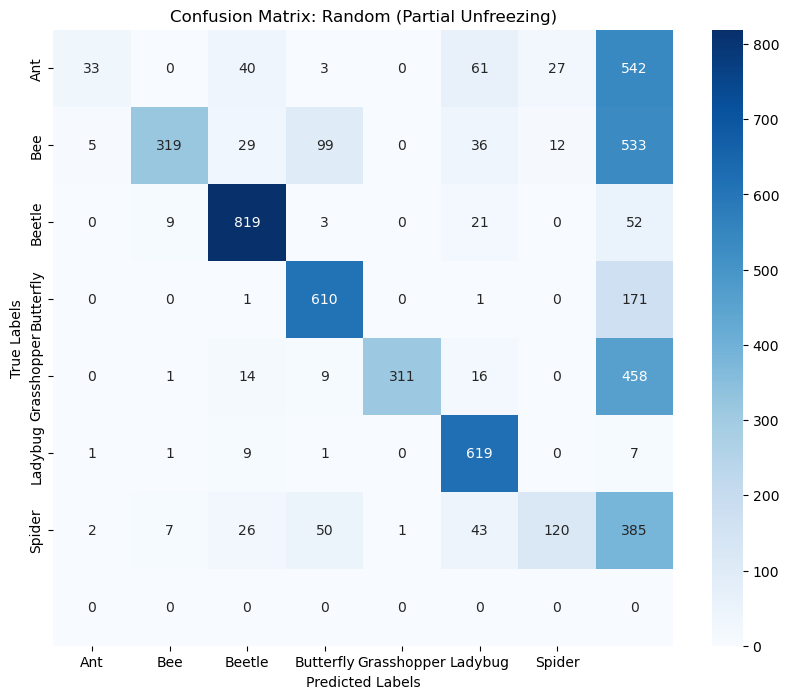

RESULT [Trial 9/10]: Acc: 0.5141 | F1: 0.5723 | AUC: 0.9466

--- Starting Experiment: Random (Partial Unfreezing) ---
Results for Random (Partial Unfreezing):
  Test Accuracy:  0.4576
  Test Weight F1: 0.5051
  Test AUC:       0.9471
  Train Time: 151.84s | Test Time: 247.7679s
  Confusion Matrix:


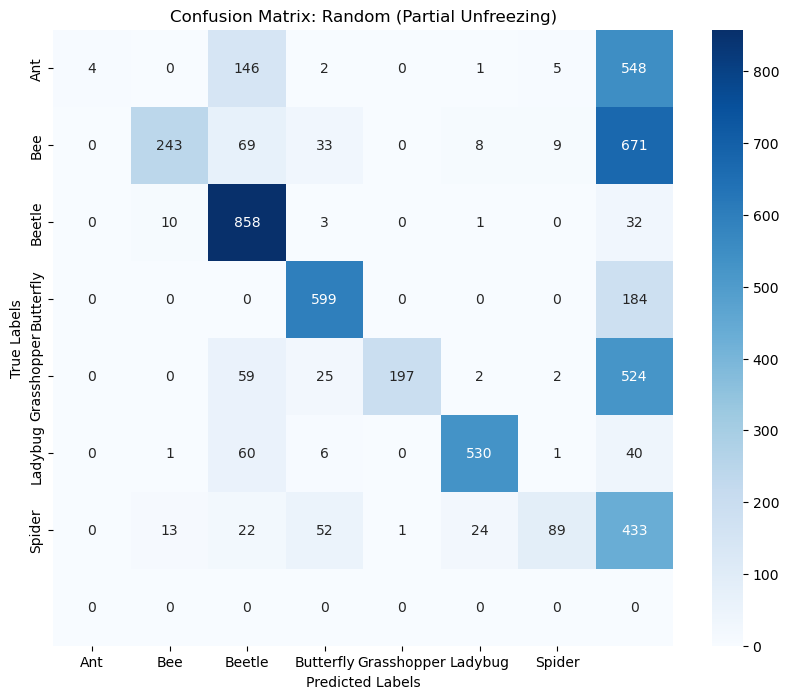

RESULT [Trial 10/10]: Acc: 0.4576 | F1: 0.5051 | AUC: 0.9471


In [41]:
target_size = len(cur_indices)
rand_metrics = []

for i in range(10):
    np.random.seed(42 + i)
    r_idx = np.random.choice(all_indices, size=target_size, replace=False).tolist()
    r_ds = InatPixelDataset(ds, r_idx, iNat36_label_df, transform=preprocess)
    
    res = run_multiple_trials("Random (Partial Unfreezing)", 
                                            get_partial_unfreeze_model, 
                                            r_ds,
                                            test_loader, 
                                            num_trials=5
                                        )
    
    # show metrics each round
    print(f"RESULT [Trial {i+1}/10]: Acc: {res['acc']:.4f} | F1: {res['f1']:.4f} | AUC: {res['auc']:.4f}")
    rand_metrics.append(res)


In [45]:
rand_metrics[0]

{'name': 'Random (Partial Unfreezing)',
 'acc': 0.5618303976756855,
 'f1': 0.6408064744831264,
 'auc': 0.9600073332490072,
 'train_time': 109.2199022769928,
 'test_time': 174.2840211391449,
 'conf_matrix': array([[ 50,   6,  49,   1,   2,  11,  78, 509],
        [  2, 390,   5,  72,  28,  16,  61, 459],
        [  0,  46, 552,  17,   4,  45,  14, 226],
        [  0,   1,   0, 605,   1,   0,   0, 176],
        [  0,   0,   0,   0, 564,   2,   0, 243],
        [  0,   1,   4,  15,   0, 562,   0,  56],
        [  1,   4,   5,  19,  14,   6, 371, 214],
        [  0,   0,   0,   0,   0,   0,   0,   0]])}

In [ ]:
results_summary['Random_partial'] = {
    'acc': np.mean([m['acc'] for m in rand_metrics]),
    'f1': np.mean([m['f1'] for m in rand_metrics]),
    'auc': np.mean([m['auc'] for m in rand_metrics]),
    'train_time': np.mean([m['train_time'] for m in rand_metrics]),
    'test_time': np.mean([m['test_time'] for m in rand_metrics]),
    'conf_matrix': rand_metrics[-1]['conf_matrix']
}

##### LoRA


--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.1364
  Test Weight F1: 0.1453
  Test AUC:       0.6940
  Train Time: 168.77s | Test Time: 235.5462s
  Confusion Matrix:


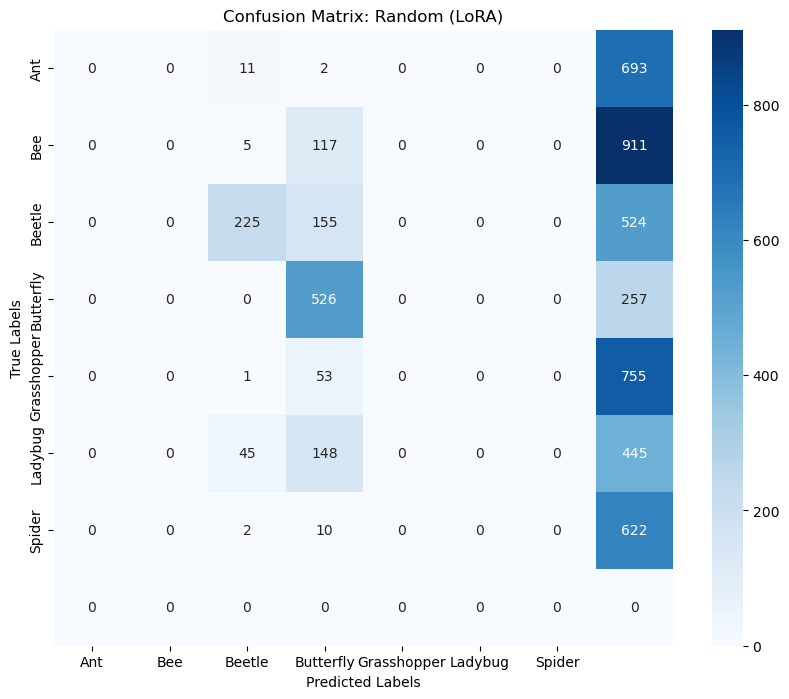

RESULT [Trial 1/10]: Acc: 0.1364 | F1: 0.1453 | AUC: 0.6940

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0098
  Test Weight F1: 0.0184
  Test AUC:       0.6161
  Train Time: 168.96s | Test Time: 251.0716s
  Confusion Matrix:


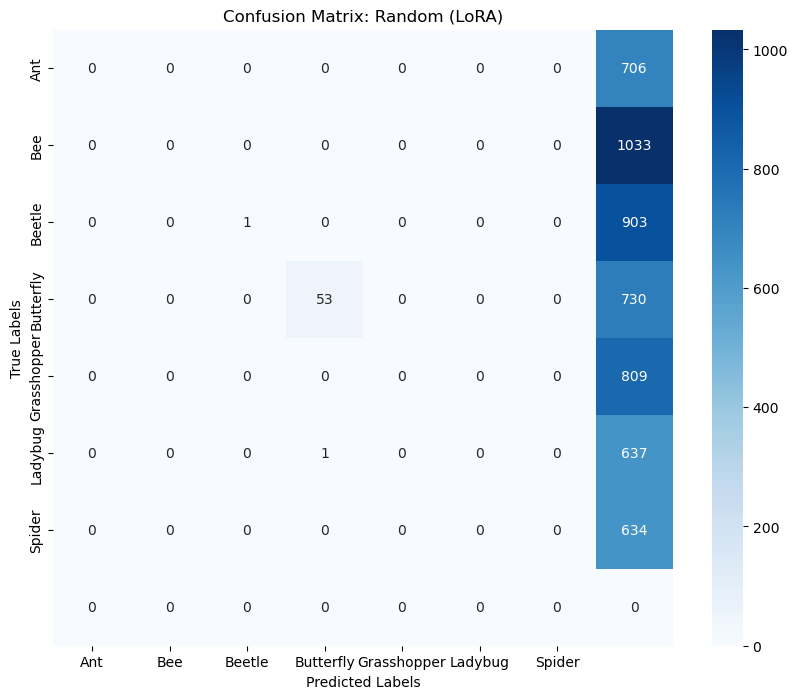

RESULT [Trial 2/10]: Acc: 0.0098 | F1: 0.0184 | AUC: 0.6161

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0225
  Test Weight F1: 0.0374
  Test AUC:       0.6020
  Train Time: 167.87s | Test Time: 263.0977s
  Confusion Matrix:


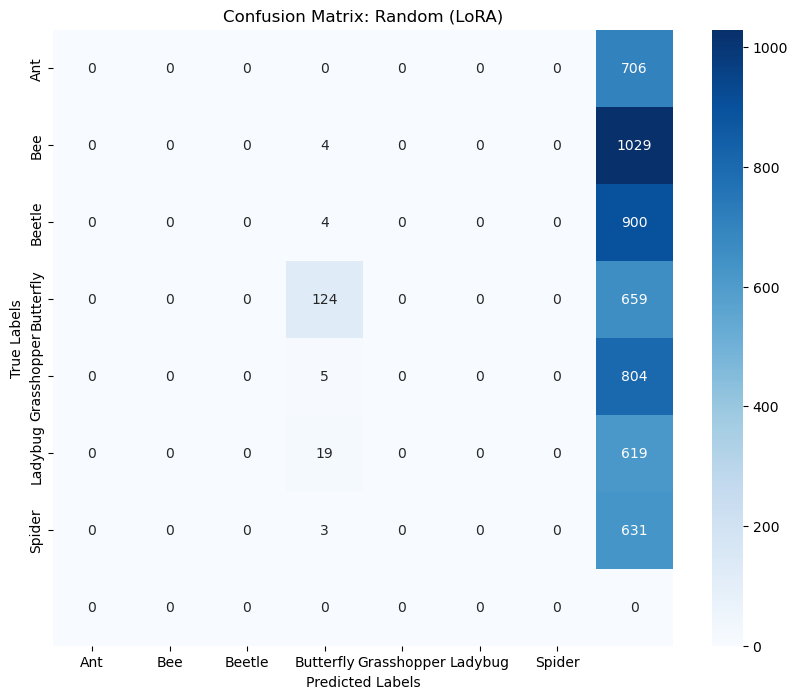

RESULT [Trial 3/10]: Acc: 0.0225 | F1: 0.0374 | AUC: 0.6020

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0189
  Test Weight F1: 0.0332
  Test AUC:       0.6335
  Train Time: 172.57s | Test Time: 260.9612s
  Confusion Matrix:


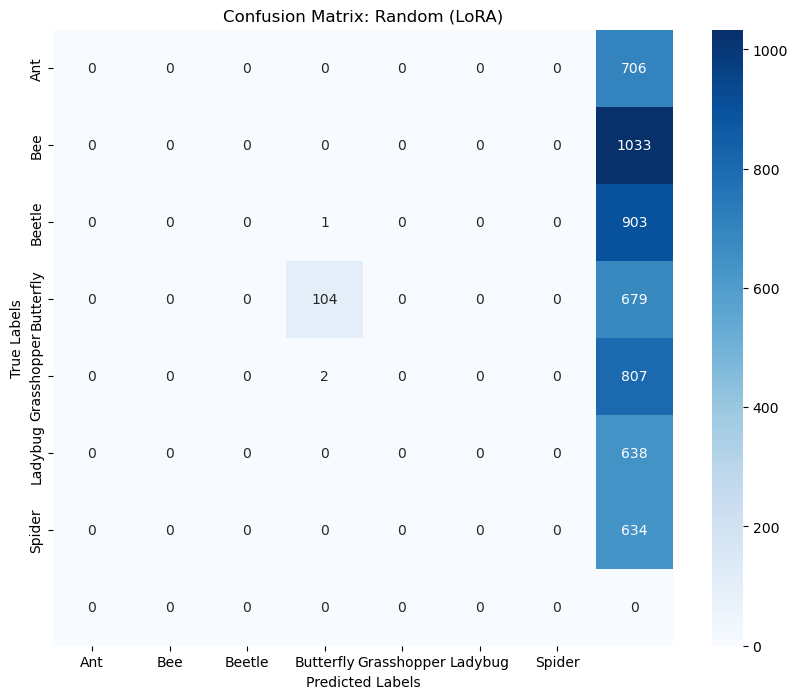

RESULT [Trial 4/10]: Acc: 0.0189 | F1: 0.0332 | AUC: 0.6335

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0002
  Test Weight F1: 0.0004
  Test AUC:       0.6070
  Train Time: 163.65s | Test Time: 201.0211s
  Confusion Matrix:


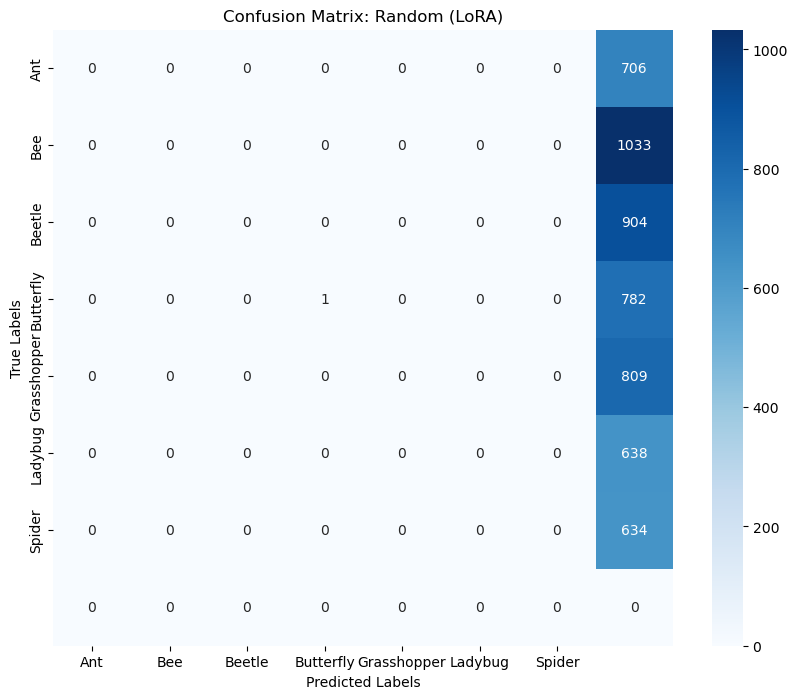

RESULT [Trial 5/10]: Acc: 0.0002 | F1: 0.0004 | AUC: 0.6070

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0263
  Test Weight F1: 0.0399
  Test AUC:       0.5628
  Train Time: 119.58s | Test Time: 195.0865s
  Confusion Matrix:


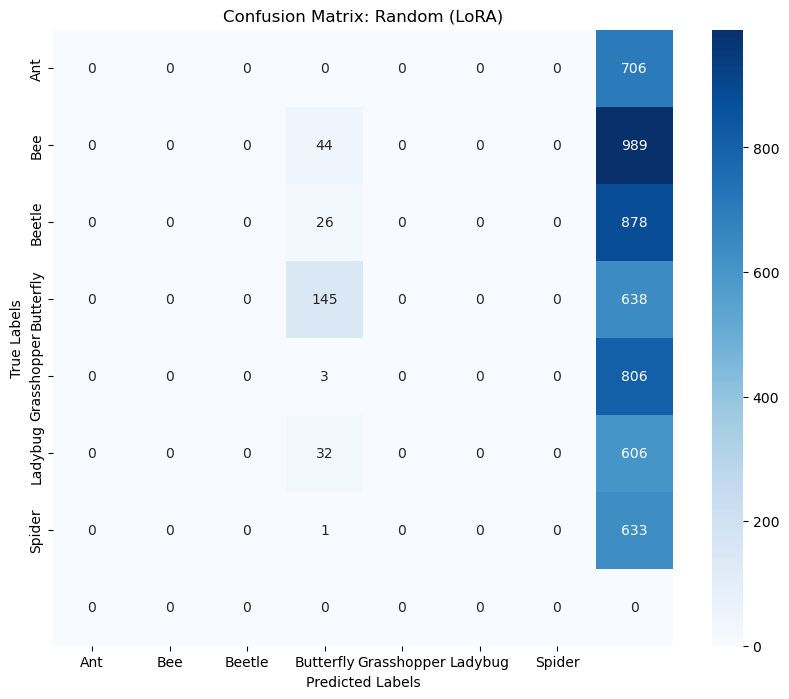

RESULT [Trial 6/10]: Acc: 0.0263 | F1: 0.0399 | AUC: 0.5628

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0009
  Test Weight F1: 0.0018
  Test AUC:       0.6404
  Train Time: 129.15s | Test Time: 195.6520s
  Confusion Matrix:


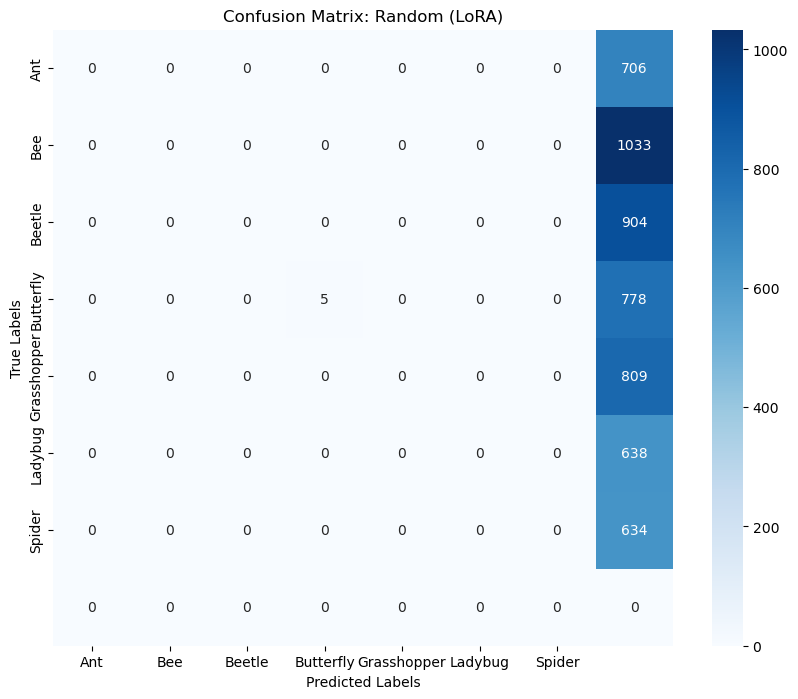

RESULT [Trial 7/10]: Acc: 0.0009 | F1: 0.0018 | AUC: 0.6404

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0000
  Test Weight F1: 0.0000
  Test AUC:       0.5650
  Train Time: 114.19s | Test Time: 166.6254s
  Confusion Matrix:


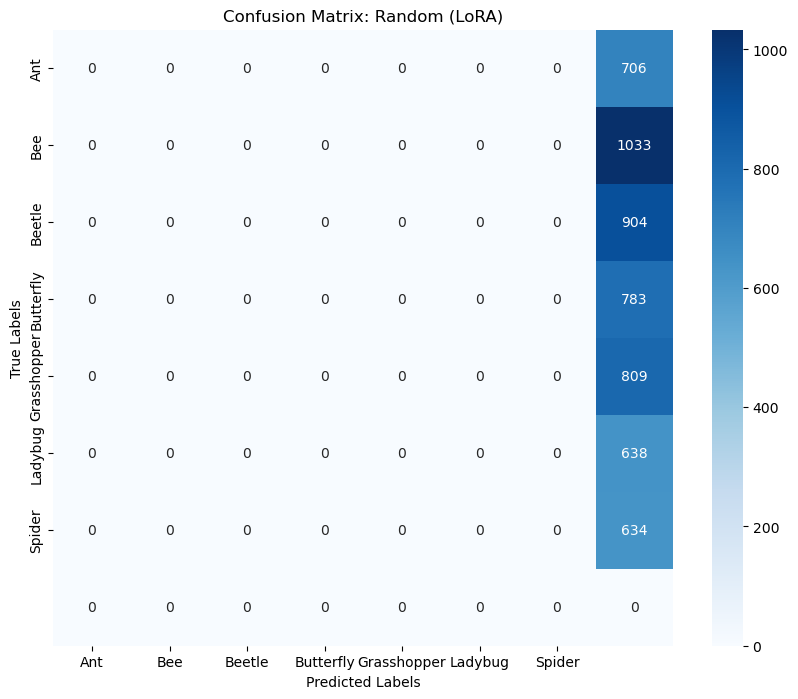

RESULT [Trial 8/10]: Acc: 0.0000 | F1: 0.0000 | AUC: 0.5650

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0597
  Test Weight F1: 0.0663
  Test AUC:       0.6607
  Train Time: 123.36s | Test Time: 170.0605s
  Confusion Matrix:


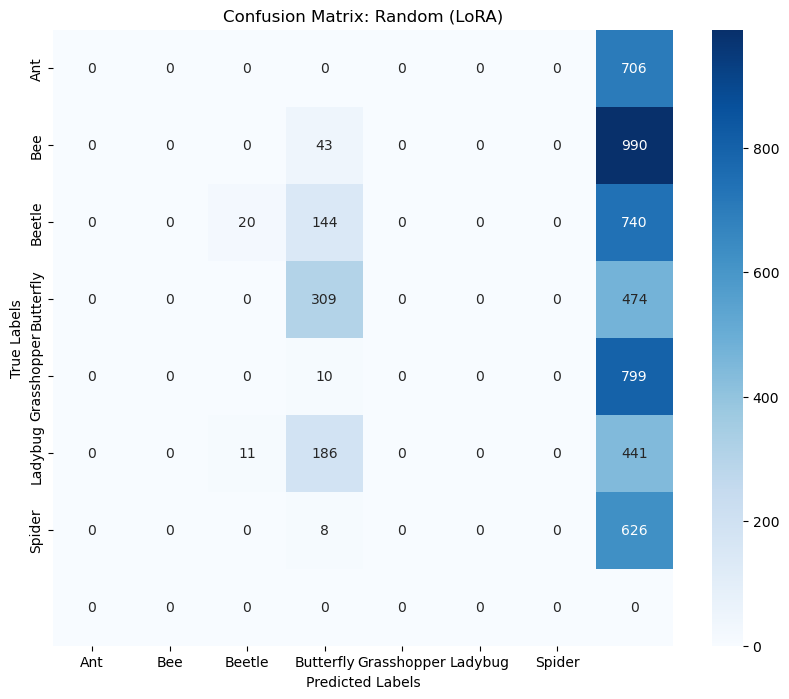

RESULT [Trial 9/10]: Acc: 0.0597 | F1: 0.0663 | AUC: 0.6607

--- Starting Experiment: Random (LoRA) ---
Results for Random (LoRA):
  Test Accuracy:  0.0176
  Test Weight F1: 0.0325
  Test AUC:       0.6158
  Train Time: 121.22s | Test Time: 172.0380s
  Confusion Matrix:


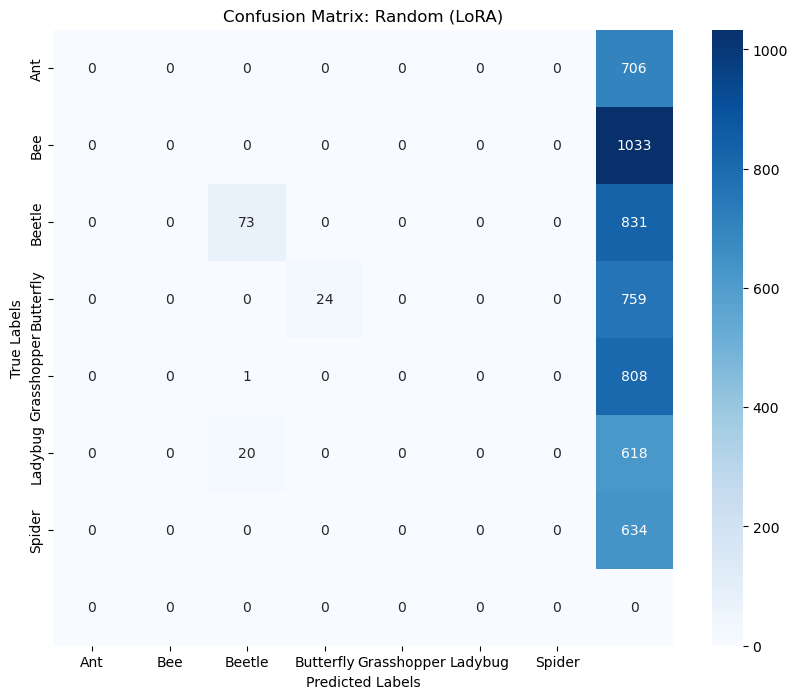

RESULT [Trial 10/10]: Acc: 0.0176 | F1: 0.0325 | AUC: 0.6158


In [51]:
target_size = len(cur_indices)
rand_metrics = []

for i in range(10):
    np.random.seed(42 + i)
    r_idx = np.random.choice(all_indices, size=target_size, replace=False).tolist()
    r_ds = InatPixelDataset(ds, r_idx, iNat36_label_df, transform=preprocess)
    
    res = run_multiple_trials("Random (LoRA)", 
                                            get_lora_model, 
                                            r_ds,
                                            test_loader, 
                                            num_trials=5
                                        )
    
    # show metrics each round
    print(f"RESULT [Trial {i+1}/10]: Acc: {res['acc']:.4f} | F1: {res['f1']:.4f} | AUC: {res['auc']:.4f}")
    rand_metrics.append(res)

In [ ]:
rand_metrics[0]

In [52]:
results_summary['Random_LoRA'] = {
    'acc': np.mean([m['acc'] for m in rand_metrics]),
    'f1': np.mean([m['f1'] for m in rand_metrics]),
    'auc': np.mean([m['auc'] for m in rand_metrics]),
    'train_time': np.mean([m['train_time'] for m in rand_metrics]),
    'test_time': np.mean([m['test_time'] for m in rand_metrics]),
    'conf_matrix': rand_metrics[-1]['conf_matrix']
}

### Experiment 2: Noise Injected Training Data

#### 2.1: Curated Noise

Trains ResNet-50 model on only the highest value samples identified by KAIROS after noise is injected into training data.

In [18]:
curated_indices = np.load('data/embs/finetuning_indexes_noisy_insects.npy')
noise_labels = np.load('data/noisified_inat_insect_labels.npy')

In [19]:
print(f"Indices: {len(curated_indices)}, Labels: {len(noise_labels)}")

Indices: 2551, Labels: 5276


In [26]:
class NoisyInsectDataset(Dataset):
    def __init__(self, img_dir, indices, all_labels, transform=None):
        self.img_dir = img_dir
        self.indices = indices      # curated_indices
        self.all_labels = all_labels # noise_labels
        self.transform = transform
    
    def __len__(self): 
        return len(self.indices)
    
    def __getitem__(self, idx):
        # get actual original index
        orig_idx = self.indices[idx]
        
        # load specific image file
        img_path = os.path.join(self.img_dir, f"img_{orig_idx}.png")
        image = Image.open(img_path).convert('RGB')
        
        # get string name and map it to number
        label_str = self.all_labels[orig_idx]
        
        label = global_label_to_idx.get(label_str, 0) 
        
        if self.transform: 
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

In [27]:
curated_noisy_ds = NoisyInsectDataset(
    img_dir='data/noisy_images', 
    indices=curated_indices, 
    all_labels=noise_labels, 
    transform=preprocess
)

##### Partial Unfreezing

In [ ]:
results_summary['noisy_curated_partial'] = run_multiple_trials("Noisy Curated (Partial Unfreezing)", 
                                            get_partial_unfreeze_model, 
                                            curated_noisy_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

##### LoRA

In [ ]:
results_summary['noisy_curated_LoRA'] = run_multiple_trials("Noisy Curated (LoRA)", 
                                            get_lora_model, 
                                            curated_noisy_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

#### 2.2: Full Noise

Trains ResNet-50 model on the entire available iNaturalist training set after noise is injected into training data.

In [31]:
# create indices for all images
full_noise_indices = np.arange(len(noise_labels)) 

print(f"Total images for training: {len(full_noise_indices)}")

Total images for training: 5276


In [32]:
full_noisy_ds = NoisyInsectDataset(
    img_dir='data/noisy_images', 
    indices=full_noise_indices, 
    all_labels=noise_labels, 
    transform=preprocess
)

##### Partial Unfreezing


--- Starting Experiment: Full Noisy Dataset (100%) ---
Epoch 1/3 - Train Acc: 0.8322, Val Acc: 0.8883
Epoch 2/3 - Train Acc: 0.9488, Val Acc: 0.9110
Epoch 3/3 - Train Acc: 0.9815, Val Acc: 0.9157
Results for Full Noisy Dataset (100%):
  Test Accuracy:  0.8117
  Test Weight F1: 0.8068
  Test AUC:       0.9761
  Train Time: 2407.02s | Test Time: 331.2539s


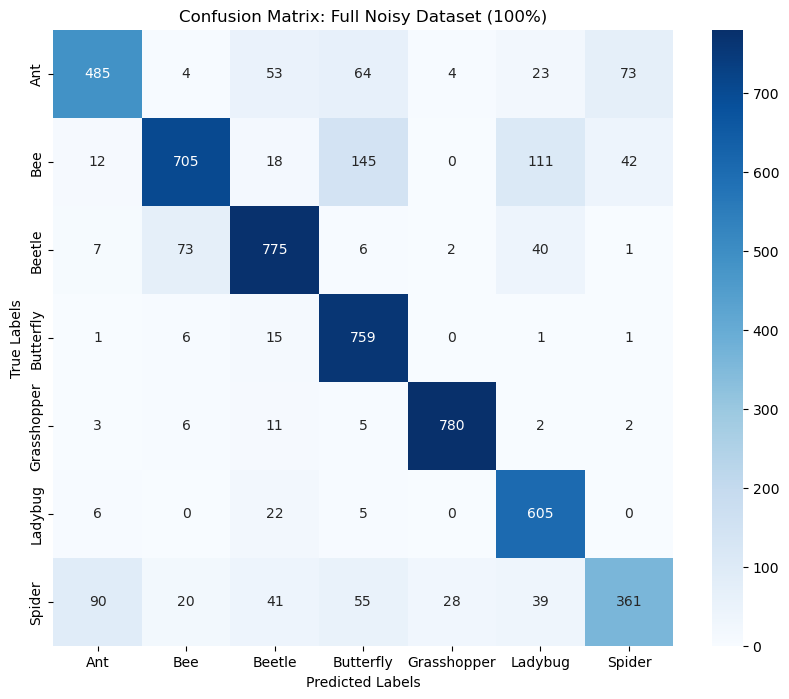

In [33]:
results_summary['noisy_full_partial'] = run_multiple_trials("Noisy Full (Partial Unfreezing)", 
                                            get_partial_unfreeze_model, 
                                            full_noisy_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

##### LoRA

In [ ]:
results_summary['noisy_full_LoRA'] = run_multiple_trials("Noisy Full (LoRA)", 
                                            get_lora_model, 
                                            full_noisy_ds,
                                            test_loader, 
                                            num_trials=5
                                        )

#### 2.3: Random Noise

Trains ResNet-50 model on 10 random subsets (same size as curated) of the iNaturalist data after noise is injected into training data.

##### Partial Unfreezing

Starting 10 Random Trials (Size: 2551) using Noisy Data...

--- Starting Experiment: Random Noisy Trial 1 ---
Epoch 1/3 - Train Acc: 0.7696, Val Acc: 0.8532
Epoch 2/3 - Train Acc: 0.9402, Val Acc: 0.8787
Epoch 3/3 - Train Acc: 0.9809, Val Acc: 0.8845
Results for Random Noisy Trial 1:
  Test Accuracy:  0.7247
  Test Weight F1: 0.7124
  Test AUC:       0.9631
  Train Time: 609.74s | Test Time: 818.0522s


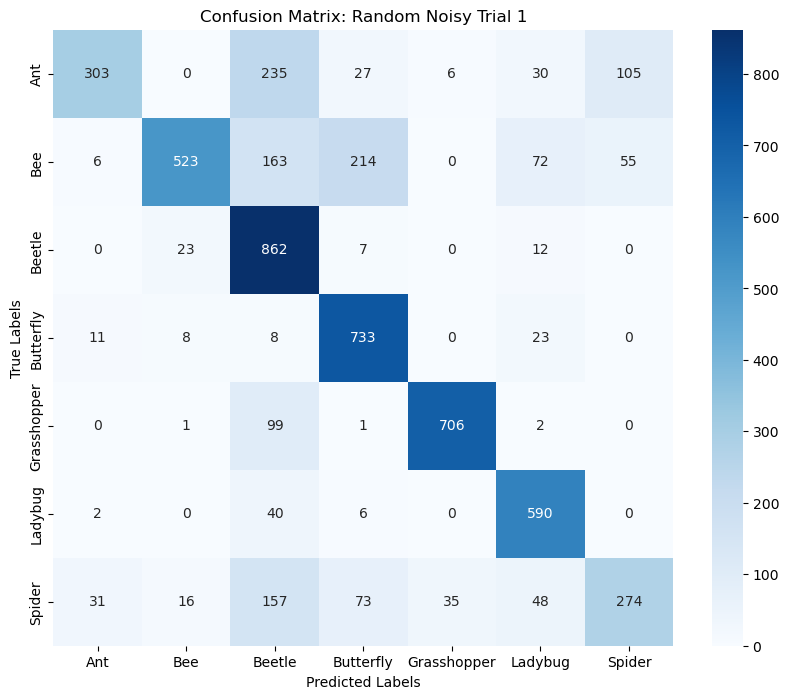

✅ TRIAL 1 FINAL: Acc: 0.7247 | F1: 0.7124 | AUC: 0.9631

--- Starting Experiment: Random Noisy Trial 2 ---
Epoch 1/3 - Train Acc: 0.7843, Val Acc: 0.8982
Epoch 2/3 - Train Acc: 0.9490, Val Acc: 0.9256
Epoch 3/3 - Train Acc: 0.9819, Val Acc: 0.9217
Results for Random Noisy Trial 2:
  Test Accuracy:  0.7509
  Test Weight F1: 0.7460
  Test AUC:       0.9705
  Train Time: 1798.44s | Test Time: 248.8538s


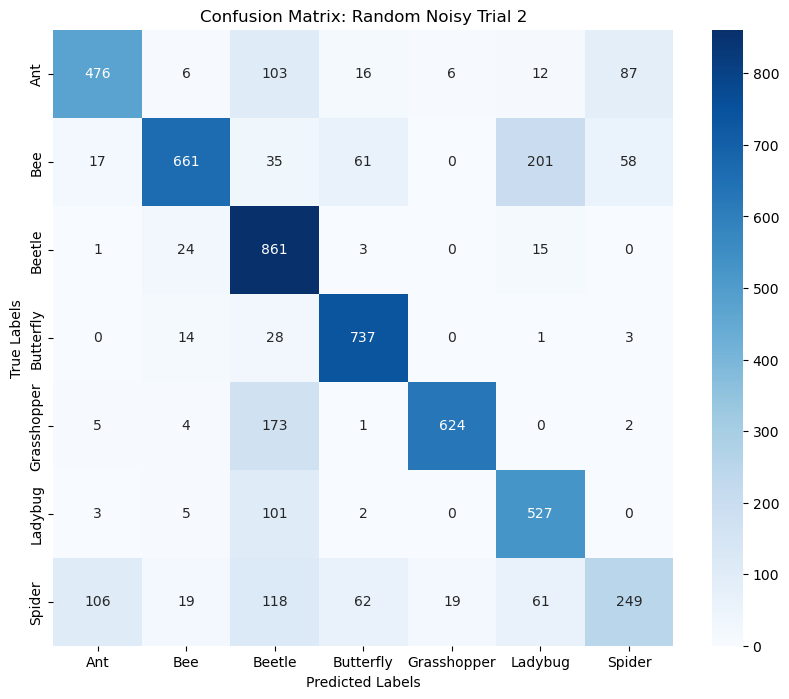

✅ TRIAL 2 FINAL: Acc: 0.7509 | F1: 0.7460 | AUC: 0.9705

--- Starting Experiment: Random Noisy Trial 3 ---
Epoch 1/3 - Train Acc: 0.7750, Val Acc: 0.8885
Epoch 2/3 - Train Acc: 0.9510, Val Acc: 0.9061
Epoch 3/3 - Train Acc: 0.9863, Val Acc: 0.8924
Results for Random Noisy Trial 3:
  Test Accuracy:  0.7587
  Test Weight F1: 0.7577
  Test AUC:       0.9458
  Train Time: 519.15s | Test Time: 279.4506s


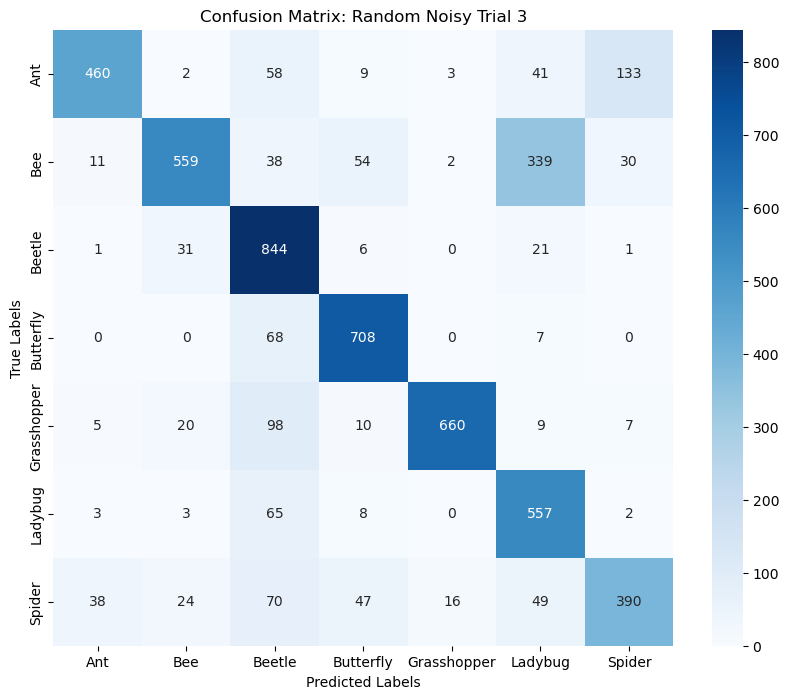

✅ TRIAL 3 FINAL: Acc: 0.7587 | F1: 0.7577 | AUC: 0.9458


In [34]:
all_noise_indices = np.arange(len(noise_labels))
target_size = len(curated_indices)
rand_metrics = []

print(f"Starting 10 Random Trials (Size: {target_size}) using Noisy Data...")

for i in range(10):
    np.random.seed(42 + i)
    
    # randomly pick 2551 indices from the 5276 pool
    r_idx = np.random.choice(all_noise_indices, size=target_size, replace=False)
    
    # initialize using the NOISY dataset class and labels
    r_ds = NoisyInsectDataset(
        img_dir='data/noisy_images', 
        indices=r_idx, 
        all_labels=noise_labels,
        transform=preprocess
    )
    
    # run trial
    res = run_multiple_trials("Noisy Random (Partial Unfreezing)", 
                                            get_partial_unfreeze_model, 
                                            r_ds,
                                            test_loader, 
                                            num_trials=5
                                        )
    
    # show summary metrics for this specific trial
    print(f"TRIAL {i+1} FINAL: Acc: {res['acc']:.4f} | F1: {res['f1']:.4f} | AUC: {res['auc']:.4f}")
    rand_metrics.append(res)

In [ ]:
rand_metrics[0]

In [ ]:
results_summary['noisy_random_partial'] = {
    'acc': np.mean([m['acc'] for m in rand_metrics]),
    'f1': np.mean([m['f1'] for m in rand_metrics]),
    'auc': np.mean([m['auc'] for m in rand_metrics]),
    'train_time': np.mean([m['train_time'] for m in rand_metrics]),
    'test_time': np.mean([m['test_time'] for m in rand_metrics]),
    'conf_matrix': rand_metrics[-1]['conf_matrix']
}

##### LoRA

In [ ]:
all_noise_indices = np.arange(len(noise_labels))
target_size = len(curated_indices)
rand_metrics = []

print(f"Starting 10 Random Trials (Size: {target_size}) using Noisy Data...")

for i in range(10):
    np.random.seed(42 + i)
    
    # randomly pick 2551 indices from the 5276 pool
    r_idx = np.random.choice(all_noise_indices, size=target_size, replace=False)
    
    # initialize using the NOISY dataset class and labels
    r_ds = NoisyInsectDataset(
        img_dir='data/noisy_images', 
        indices=r_idx, 
        all_labels=noise_labels,
        transform=preprocess
    )
    
    # run trial
    res = run_multiple_trials("Noisy Random (LoRA)", 
                                            get_lora_model, 
                                            r_ds,
                                            test_loader, 
                                            num_trials=5
                                        )
    
    # show summary metrics for this specific trial
    print(f"TRIAL {i+1} FINAL: Acc: {res['acc']:.4f} | F1: {res['f1']:.4f} | AUC: {res['auc']:.4f}")
    rand_metrics.append(res)

In [ ]:
rand_metrics[0]

In [ ]:
results_summary['noisy_random_lora'] = {
    'acc': np.mean([m['acc'] for m in rand_metrics]),
    'f1': np.mean([m['f1'] for m in rand_metrics]),
    'auc': np.mean([m['auc'] for m in rand_metrics]),
    'train_time': np.mean([m['train_time'] for m in rand_metrics]),
    'test_time': np.mean([m['test_time'] for m in rand_metrics]),
    'conf_matrix': rand_metrics[-1]['conf_matrix']
}

### All results

In [64]:
print(f"\n{'='*70}")
print(f"{'Experiment':<25} | {'Acc':<7} | {'F1':<7} | {'AUC':<7}")
print(f"{'-'*70}")
for name, m in results_summary.items():
    print(f"{name:<25} | {m['acc']:.4f} | {m['f1']:.4f} | {m['auc']:.4f}")
print(f"{'='*70}")


Experiment                | Acc     | F1      | AUC    
----------------------------------------------------------------------
Curated_partial           | 0.7427 | 0.7282 | 0.9514
Curated_LoRA              | 0.4685 | 0.4009 | 0.9130
Full_partial              | 0.6219 | 0.6998 | 0.9599
Full_LoRA                 | 0.4325 | 0.4617 | 0.9087
Random (10-avg)           | 0.4706 | 0.5298 | 0.9410
Random (LoRA)             | 0.0292 | 0.0375 | 0.6197
Baseline                  | 0.1144 | 0.0288 | 0.5037


### Experiment 3: Curated Metrics across Data Size

#### Original Training Data

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 3
SIZES = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

raw_curated = np.load('data/kairos_output/finetuning_indexes_full_curated.npy').tolist()
cur_indices = [i for i in raw_curated if iNat36_label_df.iloc[i]['clean_label'] != 'Other']

results = {'size': [], 'acc': [], 'f1': [], 'auc': [], 'time': []}

print(f"Total curated clean samples available: {len(cur_indices)}")

for s in SIZES:
    print(f"\n--- Training on top {s*100}% important Clean samples ---")
    
    num_samples = int(len(cur_indices) * s)
    selected_indices = cur_indices[-num_samples:]
    
    train_ds = InatPixelDataset(ds, selected_indices, iNat36_label_df, transform=preprocess)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    
    model = get_partial_unfreeze_model().to(DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    # training
    start_time = time.time()
    model.train()
    for epoch in range(EPOCHS):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    train_duration = time.time() - start_time
    
    # evaluation
    model.eval()
    test_preds, test_probs, test_targets = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            test_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
            test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            test_targets.extend(labels.numpy())
    
    # metric calculations
    probs_array = np.array(test_probs)[:, :7]
    probs_array = probs_array / (probs_array.sum(axis=1, keepdims=True) + 1e-10)
    
    acc = accuracy_score(test_targets, test_preds)
    f1 = f1_score(test_targets, test_preds, average='weighted')
    auc = roc_auc_score(test_targets, probs_array, multi_class='ovr', average='weighted')
    
    # save results
    results['size'].append(s * 100)
    results['acc'].append(acc)
    results['f1'].append(f1)
    results['auc'].append(auc)
    results['time'].append(train_duration)
    
    print(f"Done: {s*100}% -> Acc: {acc:.4f}, AUC: {auc:.4f}, Time: {train_duration:.1f}s")

Total curated clean samples available: 2347

--- Training on top 10.0% important Clean samples ---
Done: 10.0% -> Acc: 0.4867, AUC: 0.8987, Time: 339.7s

--- Training on top 20.0% important Clean samples ---
Done: 20.0% -> Acc: 0.7897, AUC: 0.9664, Time: 68.2s

--- Training on top 40.0% important Clean samples ---
Done: 40.0% -> Acc: 0.7601, AUC: 0.9617, Time: 123.7s

--- Training on top 60.0% important Clean samples ---


In [ ]:
metrics_to_plot = [
    ('Test Accuracy', 'acc', 'blue'),
    ('F1-Score (Weighted)', 'f1', 'green'),
    ('AUC (OVR)', 'auc', 'purple'),
    ('Training Time (s)', 'time', 'red')
]

for title, key, color in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.plot(results['size'], results[key], marker='o', linestyle='-', color=color)
    plt.title(f'{title} vs. Clean Curated Dataset Size')
    plt.xlabel('Dataset Size (% of Most Important Samples)')
    plt.ylabel(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

#### Noise Injected Training Data

In [ ]:
# load the noisy curated indices and labels
all_curated_noisy_indices = np.load('data/embs/finetuning_indexes_noisy_insects.npy')
noise_labels = np.load('data/noisified_inat_insect_labels.npy')

# experiment settings
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 3
SIZES = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

results = {'size': [], 'acc': [], 'f1': [], 'auc': [], 'time': []}

In [ ]:
for s in SIZES:
    print(f"\n--- Training on top {s*100}% of Curated Noisy Samples ---")
    
    # slicing from the end assumes the last indices are the highest valued
    num_samples = int(len(all_curated_noisy_indices) * s)
    selected_indices = all_curated_noisy_indices[-num_samples:]
    
    # initialize noisy dataset with this subset
    train_subset_ds = NoisyInsectDataset(
        img_dir='data/noisy_images', 
        indices=selected_indices, 
        all_labels=noise_labels, 
        transform=preprocess
    )
    train_loader = DataLoader(train_subset_ds, batch_size=BATCH_SIZE, shuffle=True)
    
    # initialize the model (partial unfreezing)
    model = get_partial_unfreeze_model().to(DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    # training
    start_time = time.time()
    model.train()
    for epoch in range(EPOCHS):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    train_duration = time.time() - start_time
    
    # collect metrics on clean test set
    model.eval()
    test_preds, test_probs, test_targets = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            test_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
            test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            test_targets.extend(labels.numpy())
    
    # calculate scores
    acc = accuracy_score(test_targets, test_preds)
    f1 = f1_score(test_targets, test_preds, average='weighted')
    
    probs_array = np.array(test_probs)[:, :7]
    probs_array = probs_array / (probs_array.sum(axis=1, keepdims=True) + 1e-10)
    auc = roc_auc_score(test_targets, probs_array, multi_class='ovr', average='weighted')
    
    results['size'].append(s * 100)
    results['acc'].append(acc)
    results['f1'].append(f1)
    results['auc'].append(auc)
    results['time'].append(train_duration)
    
    print(f"Done: {s*100}% size -> Acc: {acc:.4f}, F1: {f1:.4f}")


In [ ]:
metrics_to_plot = [
    ('Test Accuracy', 'acc', 'blue'),
    ('F1-Score (Weighted)', 'f1', 'green'),
    ('AUC (OVR)', 'auc', 'purple'),
    ('Training Time (s)', 'time', 'red')
]

for title, key, color in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.plot(results['size'], results[key], marker='o', linestyle='-', color=color)
    plt.title(f'{title} vs. Noisy Curated Dataset Size')
    plt.xlabel('Dataset Size (% of Curated Noisy Samples)')
    plt.ylabel(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()